**README.md**

**What did I buid?**

This project implements a formation-based UAV path planning simulation where multiple drones navigate from a start point to a goal while maintaining a fixed formation.

I use A* algoritm for collision free path plannning.
A total of 5 UAV are arranged in V shape form,and they succesfully avoid a central obstacle while preserving formation structure.

Two trajectory types are generated and compared:

1. Minimum-time trajectory (fast but aggressive)
2. Minimum-energy trajectory (smooth and efficient)

**Set Up**

Clone the repository and install dependencies:

git clone https://github.com/hema-gupta/End-term-evaluation-UAV.git
cd End-term-evaluation-UAV/end_term
pip install -r requirements.txt

**HOW TO RUN**

Run the simulation using:

python simulate.py

What happens when you run it?

A path is planned around the obstacle using A*.

Two trajectories (min-time and min-energy) are generated

Plots are automatically saved in the results/ folder:

1.Path visualization

2.Speed and acceleration comparison

A GIF animation is created showing UAVs flying in formation

The terminal prints basic performance metrics (average speed)

**WHAT EACH SCRIPT DOES ??**


1. map_setup.py — Defines the 2D grid environment, obstacle, start, and goal.

2. path_planner.py — Implements the A* algorithm to compute a collision-free path.

3. trajectory.py — Generates smooth minimum-time and minimum-energy trajectories using cubic splines.

4. formation.py — Defines the V-shaped UAV formation and relative offsets.

6. simulate.py — Runs the full pipeline: planning, trajectory generation, plotting, and animation.

7. utils.py — Contains helper functions such as distance calculations, normalization, and common math utilities used across modules.

8. config.py — Stores configurable parameters like grid size, UAV speed limits, obstacle size, and simulation settings for easy modification.

9. visualization.py — Handles plotting functions separately (path plots, trajectory graphs, and animation setup) to keep simulate.py clean.

10. metrics.py — Computes performance metrics such as total path length, average speed, energy consumption, and smoothness of trajectory.

**RESULT**

1. Path Planning Result:




This plot shows:

* Start and goal positions

* Circular obstacle

* Planned path avoiding the obstacle




2. Trajectory Comparison




Observations:


* The minimum-time trajectory reaches the goal faster due to higher velocity, but exhibits sharper acceleration changes.

* The minimum-energy trajectory is smoother with lower acceleration, making it more efficient and realistic for UAV motion.

* There is a clear trade-off between speed and energy efficiency.


3. Formation Animation

The animation  shows all UAVs moving together while maintaining formation.

* Formation remains rigid throughout the motion

* All drones successfully avoid the obstacle

* Motion is smooth and synchronized


**Formation Details**

* Formation Shape: V-shape

* Number of UAVs (N): 5

* Formation Offsets:

Each UAV maintains a fixed offset relative to the formation centroid:

(-2, 0), (-1, -1), (0, 0), (1, -1), (2, 0)

How it works:

A path is planned for the formation centroid
Each UAV follows the centroid trajectory with a fixed offset.

This ensures the formation shape is preserved at all times

**requirements.txt**

* numpy

* matplotlib

* scipy

**map_setup.py**

In [48]:
%%writefile map_setup.py

import numpy as np

GRID_SIZE = 100

start = (5,50)
goal = ( 95,50)

obstacle_centre = (50,50)
obstacle_radius = 10

SAFETY_MARGIN = 8
def is_obstacle(x,y):
  dx = x - obstacle_centre[0]
  dy= y - obstacle_centre[1]

  return dx*dx + dy*dy <= (obstacle_radius + SAFETY_MARGIN)**2



Overwriting map_setup.py


**PATH_PLANNER.PY**

In [41]:
%%writefile path_planner.py
import heapq
import numpy as np
from map_setup import GRID_SIZE, start, goal, is_obstacle

def heuristic(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

def get_neighbors(node):
    directions = [(-1,0),(1,0),(0,-1),(0,1),
                  (-1,-1),(-1,1),(1,-1),(1,1)]

    neighbors = []

    for dx, dy in directions:
        nx, ny = node[0] + dx, node[1] + dy

        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            if not is_obstacle(nx, ny):


                if dx != 0 and dy != 0:
                    if is_obstacle(node[0] + dx, node[1]) or is_obstacle(node[0], node[1] + dy):
                        continue

                neighbors.append((nx, ny))

    return neighbors

def astar():
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}
    closed_set = set()

    while open_set:
        _, current = heapq.heappop(open_set)

        if current in closed_set:
            continue

        closed_set.add(current)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current):
            tentative_g = g_score[current] + heuristic(current, neighbor)

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, neighbor))

    return None

Overwriting path_planner.py


**trajectory.py**

In [42]:
%%writefile trajectory.py
import numpy as np
from scipy.interpolate import CubicSpline

def generate_trajectory(path, speed=1.0):
    path = np.array(path)


    t = np.linspace(0, len(path)-1, len(path))

    cs_x = CubicSpline(t, path[:, 0])
    cs_y = CubicSpline(t, path[:, 1])

    t_fine = np.linspace(0, len(path)-1, 500)

    x = cs_x(t_fine)
    y = cs_y(t_fine)

    vx = np.gradient(x) * speed
    vy = np.gradient(y) * speed

    speed_profile = np.sqrt(vx**2 + vy**2)
    accel = np.gradient(speed_profile)

    return x, y, t_fine, speed_profile, accel


def min_time_traj(path):
    return generate_trajectory(path, speed=2.0)


def min_energy_traj(path):
    return generate_trajectory(path, speed=0.8)

Overwriting trajectory.py


**formation.py**

In [43]:
%%writefile formation.py

import numpy as np

def get_formation_offsets():
    return np.array([
        (-8, 0),
        (-4, -4),
        (0, 0),
        (4, -4),
        (8, 0)
    ])


def apply_formation(x, y):

     offsets = get_formation_offsets()

     centroid = np.array([x, y])
     drones = offsets + centroid

     return drones

Overwriting formation.py


**simulate.py**

In [44]:
%%writefile simulate.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import os

from map_setup import *
from path_planner import astar
from trajectory import min_time_traj, min_energy_traj
from formation import apply_formation


os.makedirs("results", exist_ok=True)


path = astar()
path = np.array(path)


x1, y1, t1, s1, a1 = min_time_traj(path)
x2, y2, t2, s2, a2 = min_energy_traj(path)

# -------- Plot Path --------
plt.figure()
plt.plot(path[:,0], path[:,1], label="Path")

circle = plt.Circle(obstacle_centre, obstacle_radius, color='r')
plt.gca().add_patch(circle)

plt.scatter(*start, color='green', label='Start')
plt.scatter(*goal, color='blue', label='Goal')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Path Planning")
plt.legend()

plt.savefig("results/path_plot.png")
plt.close()

# -------- Trajectory Comparison --------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t1, s1, label="Min Time")
plt.plot(t2, s2, label="Min Energy")
plt.title("Speed vs Time")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t1, a1, label="Min Time")
plt.plot(t2, a2, label="Min Energy")
plt.title("Acceleration vs Time")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()

plt.savefig("results/trajectory_comparison.png")
plt.close()

# -------- Animation --------
fig, ax = plt.subplots()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

circle = plt.Circle(obstacle_centre, obstacle_radius, color='r')
ax.add_patch(circle)

points = [ax.plot([], [], 'bo')[0] for _ in range(5)]

def update(frame):
    drones = apply_formation(x1[frame], y1[frame])

    for i, p in enumerate(points):
        p.set_data([drones[i][0]], [drones[i][1]])

    return points

ani = FuncAnimation(fig, update, frames=len(x1), interval=50)


ani.save("results/formation_animation.gif")

print("Simulation complete!")
print("Min-time avg speed:", np.mean(s1))
print("Min-energy avg speed:", np.mean(s2))

Overwriting simulate.py


In [50]:
!python simulate.py

Simulation complete!
Min-time avg speed: 0.40677804917874244
Min-energy avg speed: 0.162711219671497


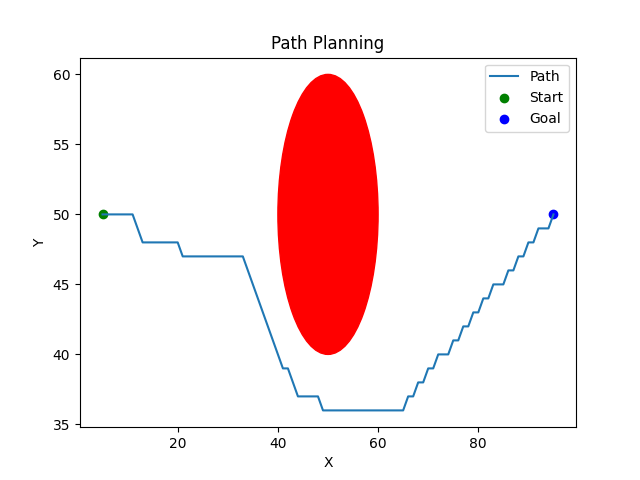

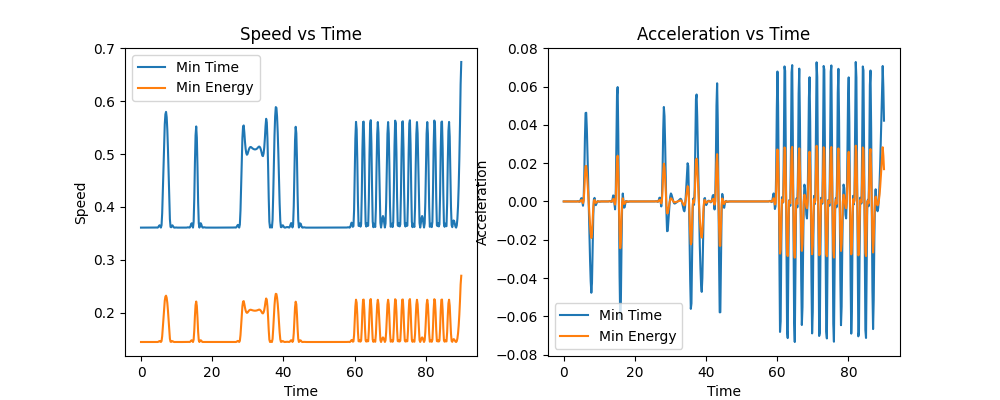

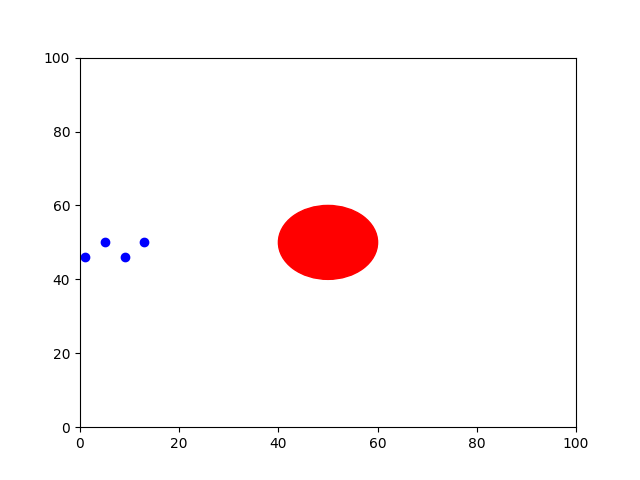

In [46]:
from IPython.display import display, Image

display(Image("results/path_plot.png"))
display(Image("results/trajectory_comparison.png"))
display(Image("results/formation_animation.gif"))